# Sensitivity analysis for geothermal doublet injection pressure

This notebook estimates the injection-well pressure for a geothermal doublet using a simplified analytical approach based on the Theis solution. The objective is to quantify uncertainty and parameter sensitivity of the time-dependent pressure increase at the injection well.

## Modeling idea and simplification

To isolate the dominant pressure behavior at the injection well, we assume the extraction well is far enough away that its hydraulic influence at the injection well is negligible.

Under this assumption, the near-well pressure response can be approximated by a single-well confined-aquifer Theis model, complemented by optional skin and linear scaling-loss terms.

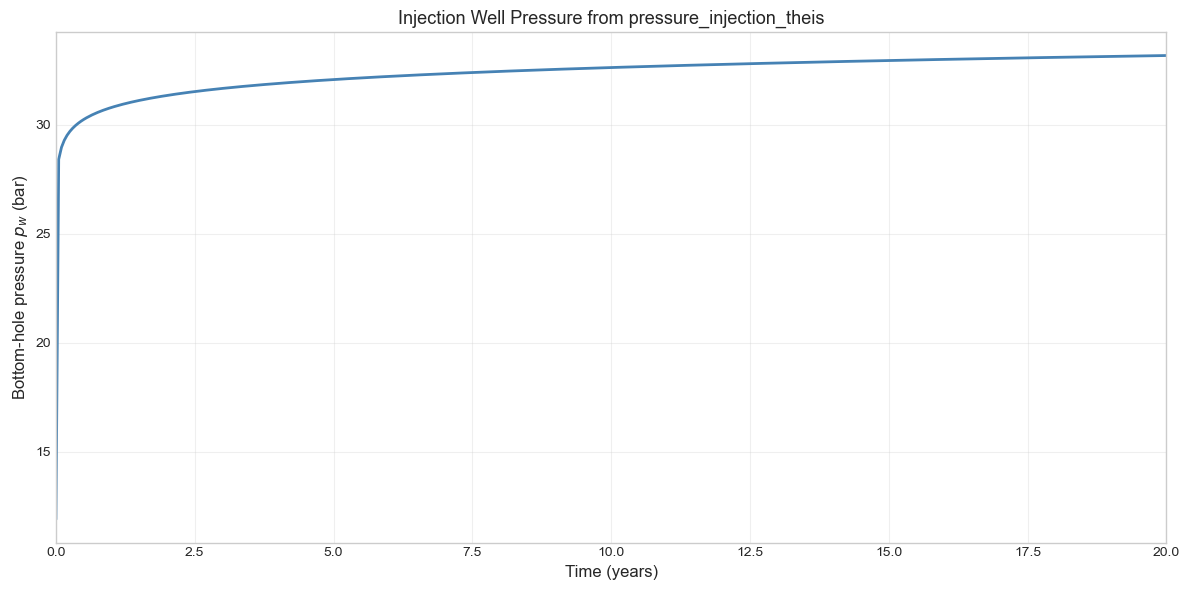

In [5]:
# Cell 1: Plot pressure_injection_theis(t)
import numpy as np
import matplotlib.pyplot as plt
from theis import pressure_injection_theis, transmissivity

# Style consistent with sensitivity.ipynb
plt.style.use('seaborn-v0_8-whitegrid')

# Figure size constants (consistent with sensitivity.ipynb)
FIGSIZE_SINGLE = (12, 6)
FIGSIZE_SUBPLOTS = (14, 6)

# Example parameter set
M = 30.0           # m
k = 1e-12          # m^2
Q = -0.03          # m^3/s (injection < 0)
S = 1e-4           # -
rw = 0.1           # m
rho_F = 1000.0     # kg/m^3
mu = 1e-3          # Pa*s
g = 9.81           # m/s^2
p_res = 1.0e6      # Pa
skin = 2.0         # -
scale_loss_grad = 1e6  # Pa/(m^3/s)

T = transmissivity(M, k, rho_F, g, mu)

# Time axis: approximately 0 to 20 years
t_years = np.linspace(0.0, 20.0, 400)
t_seconds = t_years * 365.0 * 24.0 * 3600.0
p_w = pressure_injection_theis(
    t_seconds, Q, T, S, rw, rho_F, g, p_res,
    skin=skin,
    scale_loss_grad=scale_loss_grad,
 )

plt.figure(figsize=FIGSIZE_SINGLE)
plt.plot(t_years, p_w / 1e5, color='steelblue', linewidth=2)
plt.xlabel('Time (years)', fontsize=12)
plt.ylabel('Bottom-hole pressure $p_w$ (bar)', fontsize=12)
plt.title('Injection Well Pressure from pressure_injection_theis', fontsize=13)
plt.grid(True, alpha=0.3)
plt.xlim(0, 20)
plt.tight_layout()
plt.show()


## Parameter ranges

Define physically plausible uncertainty ranges for the hydraulic and fluid properties used in the Theis-based pressure model.

The storativity $S$ is **not sampled directly** but derived from its physical components:

$$S = S_s \cdot M, \quad S_s = \rho_F g (\alpha + \phi \beta)$$

where $\alpha$ [1/Pa] is matrix compressibility, $\phi$ [-] is porosity, and $\beta$ [1/Pa] is fluid compressibility. The three parameters $\alpha$, $\phi$, $\beta$ are sampled individually to reflect physically meaningful uncertainty.

The reservoir pressure is intentionally fixed to `p_res = 0` in the sensitivity workflow so that only pressure increase (`Δp`) is analyzed.


In [6]:
# Parameter bounds for the geothermal doublet system
# Order: M, k, Q, alpha, phi, beta, rw, rho_F, mu, skin, scale_loss_grad
# Units: [m], [m^2], [m^3/s], [1/Pa], [-], [1/Pa], [m], [kg/m^3], [Pa*s], [-], [Pa/(m^3/s)]
# Storativity S is derived: S = rho_F * g * (alpha + phi * beta) * M
bounds = np.array([
    [25, 35],            # M:              aquifer thickness [m]
    [1e-12, 3e-12],      # k:              intrinsic permeability [m^2]
    [-0.035, -0.025],    # Q:              well rate (negative for injection) [m^3/s]
    [1e-10, 1e-8],       # alpha:          matrix compressibility [1/Pa]
    [0.05, 0.30],        # phi:            porosity [-]
    [4.0e-10, 5.0e-10],  # beta:           fluid compressibility [1/Pa]
    [0.2, 0.25],         # rw:             well radius [m]
    [980.0, 1200.0],     # rho_F:          fluid density [kg/m^3]
    [3e-4, 2e-3],        # mu:             dynamic viscosity [Pa*s]
    [0.0, 20.0],         # skin:           dimensionless skin factor [-]
    [0.0, 5e7],          # scale_loss_grad: linear scaling-loss coefficient [Pa/(m^3/s)]
], dtype=float)

param_names = ['M', 'k', 'Q', 'alpha', 'phi', 'beta', 'rw', 'rho_F', 'mu', 'skin', 'scale_loss_grad']
param_labels = [
    r'$M$',
    r'$k$',
    r'$Q$',
    r'$\alpha$',
    r'$\varphi$',
    r'$\beta$',
    r'$r_w$',
    r'$\rho_F$',
    r'$\mu$',
    r'$S$',
    r'$C$',
]

assert bounds.shape == (11, 2), f'Expected bounds shape (11, 2), got {bounds.shape}'
assert np.all(bounds[:, 0] < bounds[:, 1]), 'Lower bounds must be strictly less than upper bounds'
assert np.all(np.isfinite(bounds)), 'Bounds contain NaN or inf values'

print('Bounds validation passed.')
print('Storativity S is derived: S = rho_F * g * (alpha + phi * beta) * M')
print('Reservoir pressure p_res is fixed to 0 Pa for sensitivity analysis.')
print(f'Parameters ({len(param_names)}): {param_names}')


Bounds validation passed.
Storativity S is derived: S = rho_F * g * (alpha + phi * beta) * M
Reservoir pressure p_res is fixed to 0 Pa for sensitivity analysis.
Parameters (11): ['M', 'k', 'Q', 'alpha', 'phi', 'beta', 'rw', 'rho_F', 'mu', 'skin', 'scale_loss_grad']


## Sensitivity analysis for injection-pressure increase

This section combines uncertainty quantification and sensitivity analysis for the time-dependent **injection-pressure increase** predicted by the Theis-based model.

### 1. Uncertainty Quantification (LHS)

Pressure-increase curves are evaluated over the full parameter space using Latin Hypercube Sampling (LHS), a quasi-random sampling approach with efficient coverage.

**Method: Latin Hypercube Sampling**
- More efficient than simple Monte Carlo sampling due to better parameter-space coverage with fewer samples
- Each parameter range is split into N equally probable intervals, with one sample drawn per interval
- Produces stable uncertainty bands for the pressure response

**Outputs:**
- **Quantile bands** for pressure increase over time
  - 50% quantile (25th-75th percentile): central spread of realizations
  - 90% quantile (5th-95th percentile): broad uncertainty envelope
- **Mean and median pressure-increase curves** as central tendency measures

### 2. Global Sobol Sensitivity Analysis (L2 norm)

Sobol indices are computed using the L2 norm of each pressure-increase curve relative to the mean pressure-increase curve. This yields one scalar sensitivity target per realization while retaining full time-series behavior in the metric.

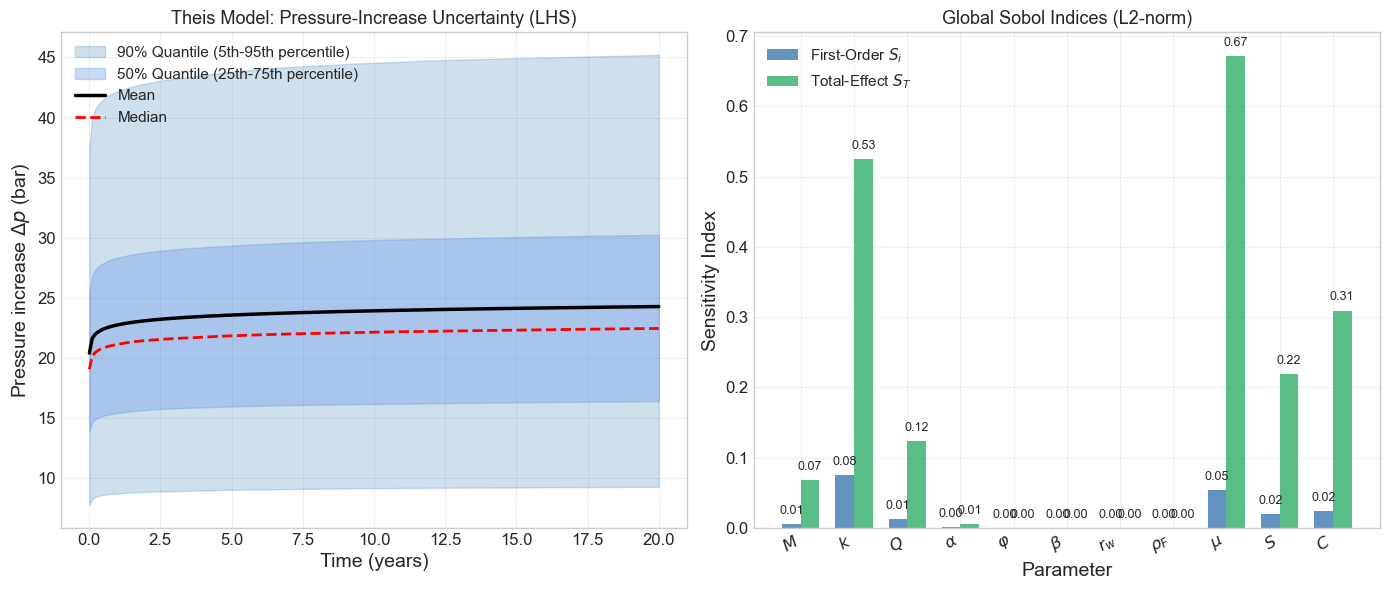

In [ ]:
import numpy as np
from scipy.stats import qmc
from geothermal_utils import compute_sobol_indices
from theis import transmissivity, pressure_injection_theis

# Constants
g = 9.81
p_res = 0.0  # Fixed reservoir pressure: analyze pressure increase only
N_samples = 10000
SEED_A = 789
SEED_B = 999

# Time vector for pressure curves
t_years = np.linspace(0.01, 20.0, 200)
t_seconds = t_years * 365.0 * 24.0 * 3600.0

def pressure_curve_theis_batch(t_array_seconds, params):
    """Compute pressure curves for parameter matrix with pressure_injection_theis.

    Parameters order: M, k, Q, alpha, phi, beta, rw, rho_F, mu, skin, scale_loss_grad
    Storativity S is derived: S = rho_F * g * (alpha + phi * beta) * M
    """
    curves = np.zeros((params.shape[0], t_array_seconds.size), dtype=float)

    for idx, (M, k, Q, alpha, phi, beta, rw, rho_F, mu, skin, scale_loss_grad) in enumerate(params):
        # Derive storativity from physical components: S = Ss * M, Ss = rho_F*g*(alpha + phi*beta)
        S = rho_F * g * (alpha + phi * beta) * M
        T = transmissivity(M, k, rho_F, g, mu)
        p_w = pressure_injection_theis(
            t_array=t_array_seconds,
            Q=Q,
            T=T,
            S=S,
            rw=rw,
            rho=rho_F,
            g=g,
            p_res=p_res,
            skin=skin,
            scale_loss_grad=scale_loss_grad,
        )

        # Pressure increase relative to reservoir pressure (here p_res = 0)
        curves[idx, :] = (p_w - p_res) / 1e5  # pressure increase in bar

    return curves

num_params = bounds.shape[0]
l_bounds = bounds[:, 0]
u_bounds = bounds[:, 1]

sampler_A = qmc.LatinHypercube(d=num_params, seed=SEED_A)
sampler_B = qmc.LatinHypercube(d=num_params, seed=SEED_B)
A = qmc.scale(sampler_A.random(n=N_samples), l_bounds, u_bounds)
B = qmc.scale(sampler_B.random(n=N_samples), l_bounds, u_bounds)

Y_A = pressure_curve_theis_batch(t_seconds, A)
Y_B = pressure_curve_theis_batch(t_seconds, B)

Y_ABi = {}
for i in range(num_params):
    ABi = A.copy()
    ABi[:, i] = B[:, i]
    Y_ABi[i] = pressure_curve_theis_batch(t_seconds, ABi)

# L2 norm aggregation of full curves to scalar output
y_mean = Y_A.mean(axis=0)
y_A_l2 = np.sqrt(np.sum((Y_A - y_mean) ** 2, axis=1))
y_B_l2 = np.sqrt(np.sum((Y_B - y_mean) ** 2, axis=1))

Y_ABi_l2 = {}
for i in range(num_params):
    Y_ABi_l2[i] = np.sqrt(np.sum((Y_ABi[i] - y_mean) ** 2, axis=1))

S_first, S_total = compute_sobol_indices(A, B, y_A_l2, y_B_l2, Y_ABi_l2, num_params)

# Uncertainty bands for visualization
y_median = np.median(Y_A, axis=0)
y_q05, y_q25, y_q75, y_q95 = np.percentile(Y_A, [5, 25, 75, 95], axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIGSIZE_SUBPLOTS)

# Left: uncertainty bands of Theis pressure increase
ax1.fill_between(t_years, y_q05, y_q95, alpha=0.25, color='steelblue',
                 label='90% Quantile (5th-95th percentile)')
ax1.fill_between(t_years, y_q25, y_q75, alpha=0.35, color='cornflowerblue',
                 label='50% Quantile (25th-75th percentile)')
ax1.plot(t_years, y_mean, 'k-', linewidth=2.5, label='Mean')
ax1.plot(t_years, y_median, 'r--', linewidth=2, label='Median')
ax1.set_xlabel('Time (years)', fontsize=14)
ax1.set_ylabel('Pressure increase $\Delta p$ (bar)', fontsize=14)
ax1.set_title('Theis Model: Pressure-Increase Uncertainty (LHS)', fontsize=13)
ax1.legend(loc='best', fontsize=11)
ax1.tick_params(labelsize=12)
ax1.grid(True, alpha=0.3)

# Right: Sobol indices
x = np.arange(num_params)
width = 0.35
ax2.bar(x - width / 2, S_first, width, label='First-Order $S_i$', alpha=0.85, color='steelblue')
ax2.bar(x + width / 2, S_total, width, label='Total-Effect $S_T$', alpha=0.85, color='mediumseagreen')
ax2.set_ylabel('Sensitivity Index', fontsize=14)
ax2.set_xlabel('Parameter', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(param_labels, fontsize=12)
ax2.legend(fontsize=11)
ax2.set_title('Global Sobol Indices (L2-norm)', fontsize=13)
ax2.tick_params(axis='y', labelsize=12)
ax2.grid(True, alpha=0.3)

for i in range(num_params):
    ax2.text(i - width / 2, S_first[i] + 0.01, f'{S_first[i]:.2f}', ha='center', va='bottom', fontsize=9)
    ax2.text(i + width / 2, S_total[i] + 0.01, f'{S_total[i]:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('sobol_pressure_curve.svg', bbox_inches='tight')
plt.show()


Target: 10.0 years  →  Closest time point: 9.955 years (index 99)


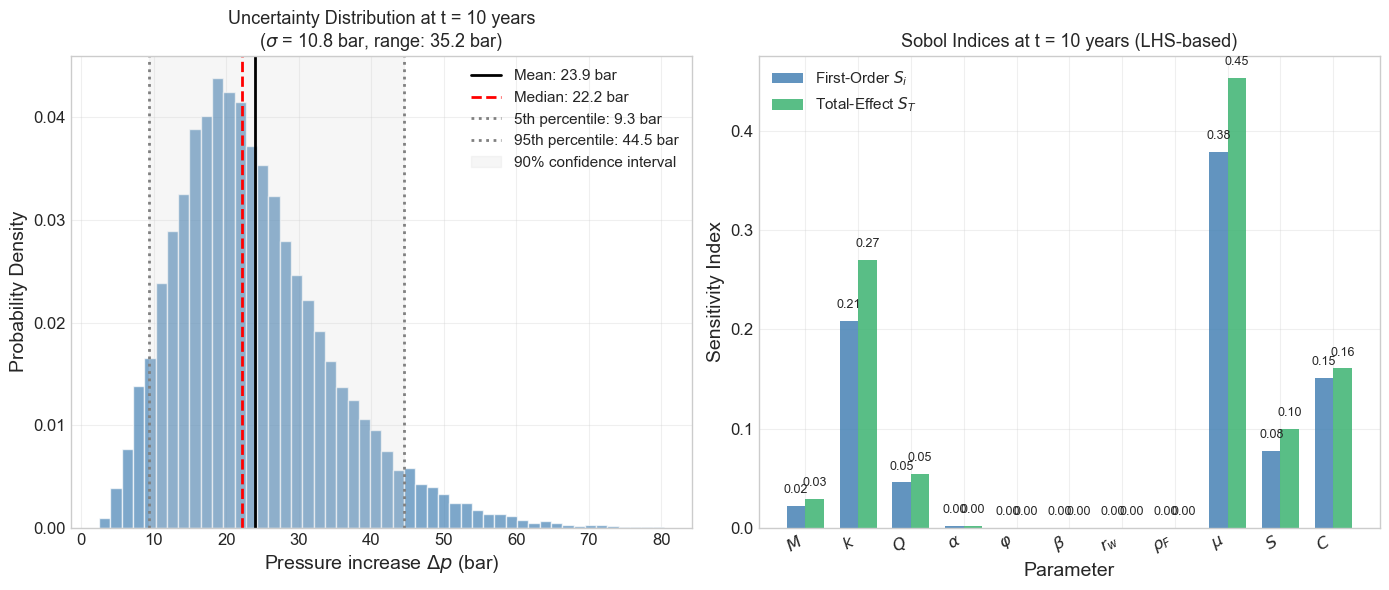

In [ ]:

# ============================================================
# Pressure at t = 10 years: Histogram + Sobol Indices
# Analogous to sensitivity.ipynb Cell 9 (breakthrough time analysis)
# ============================================================

# Find the index in t_years closest to 10 years
t_target = 10.0  # years
t_idx = np.argmin(np.abs(t_years - t_target))
t_actual = t_years[t_idx]
print(f"Target: {t_target} years  →  Closest time point: {t_actual:.3f} years (index {t_idx})")

# Extract scalar pressure values at t = 10 years from pre-computed arrays
p_A_10 = Y_A[:, t_idx]   # Pressure increase (bar) at t=10y for A samples
p_B_10 = Y_B[:, t_idx]   # Pressure increase (bar) at t=10y for B samples

Y_ABi_10 = {i: Y_ABi[i][:, t_idx] for i in range(num_params)}

# Compute Sobol indices for pressure at t = 10 years
S_first_10, S_total_10 = compute_sobol_indices(A, B, p_A_10, p_B_10, Y_ABi_10, num_params)

# ============================================================
# Histogram statistics
# Concatenate A and B samples for more stable quantile estimates
# ============================================================
pressure_10y = np.concatenate([p_A_10, p_B_10])
p_mean   = np.mean(pressure_10y)
p_std    = np.std(pressure_10y)
p_median = np.median(pressure_10y)
p_q05, p_q95 = np.percentile(pressure_10y, [5, 95])

# ============================================================
# Combined visualization (side-by-side)
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIGSIZE_SUBPLOTS)

# Left: Histogram of pressure-increase distribution at t = 10 years
ax1.hist(pressure_10y, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
ax1.axvline(p_mean,   color='black', linestyle='-',  linewidth=2.0, label=f'Mean: {p_mean:.1f} bar')
ax1.axvline(p_median, color='red',   linestyle='--', linewidth=2,   label=f'Median: {p_median:.1f} bar')
ax1.axvline(p_q05,    color='gray',  linestyle=':',  linewidth=2,   label=f'5th percentile: {p_q05:.1f} bar')
ax1.axvline(p_q95,    color='gray',  linestyle=':',  linewidth=2,   label=f'95th percentile: {p_q95:.1f} bar')
ax1.axvspan(p_q05, p_q95, alpha=0.2, color='lightgray', label='90% confidence interval')
ax1.set_xlabel('Pressure increase $\Delta p$ (bar)', fontsize=14)
ax1.set_ylabel('Probability Density', fontsize=14)
ax1.set_title(
    f'Uncertainty Distribution at t = {t_actual:.0f} years\n'
    f'($\sigma$ = {p_std:.1f} bar, range: {p_q95 - p_q05:.1f} bar)',
    fontsize=13
)
ax1.legend(loc='best', fontsize=11)
ax1.tick_params(labelsize=12)
ax1.grid(True, alpha=0.3)

# Right: Sobol indices (first-order and total-effect)
x = np.arange(num_params)
width = 0.35
ax2.bar(x - width / 2, S_first_10, width, label='First-Order $S_i$',   alpha=0.85, color='steelblue')
ax2.bar(x + width / 2, S_total_10, width, label='Total-Effect $S_T$', alpha=0.85, color='mediumseagreen')
ax2.set_ylabel('Sensitivity Index', fontsize=14)
ax2.set_xlabel('Parameter', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(param_labels, fontsize=12)
ax2.legend(fontsize=11)
ax2.set_title(f'Sobol Indices at t = {t_actual:.0f} years (LHS-based)', fontsize=13)
ax2.tick_params(axis='y', labelsize=12)
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for i in range(num_params):
    ax2.text(i - width / 2, S_first_10[i] + 0.01, f'{S_first_10[i]:.2f}', ha='center', va='bottom', fontsize=9)
    ax2.text(i + width / 2, S_total_10[i] + 0.01, f'{S_total_10[i]:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('sobol_pressure_10y.svg', bbox_inches='tight')
plt.show()
